# **Gradient Boosting Regression**

# Gradient Boosting for Regression: Step-by-Step Intuition

**The Core Idea:** Instead of trying to build one massive decision tree that predicts the target variable perfectly, Gradient Boosting builds a sequence of small, weak decision trees. **Each new tree is trained solely to predict the mistakes (errors/residuals) made by the previous trees.**


## 1. The Mini Dataset
Let's imagine we are trying to predict a person's **Weight** based on their **Height** and **Age**. We have a tiny dataset of 4 people.

| Person | Height (cm) | Age | Actual Weight (kg) ($y$) |
| :---: | :---: | :---: | :---: |
| **A** | 160 | 25 | 60 |
| **B** | 170 | 30 | 70 |
| **C** | 180 | 35 | 80 |
| **D** | 150 | 22 | 50 |


## Step 1: The Initial Prediction ($F_0$)
Gradient Boosting doesn't start with a tree. It starts with a simple "baseline" guess for every single row. For regression, the mathematical best initial guess to minimize the Mean Squared Error (MSE) is simply the **average of the target variable**.

* Average Weight = $(60 + 70 + 80 + 50) / 4 = 65 \text{ kg}$

Let's update our table with this initial prediction ($F_0$):

| Person | Actual Weight ($y$) | Initial Prediction ($F_0$) |
| :---: | :---: | :---: |
| **A** | 60 | 65 |
| **B** | 70 | 65 |
| **C** | 80 | 65 |
| **D** | 50 | 65 |


## Step 2: Calculate the Errors (Residuals)
Now, the algorithm evaluates how bad its initial guess was. It calculates the **pseudo-residuals** (errors) for each person. 
*Formula:* `Residual = Actual - Predicted`

| Person | Actual ($y$) | Prediction ($F_0$) | **Residual 1 ($r_1$)** |
| :---: | :---: | :---: | :---: |
| **A** | 60 | 65 | **-5** |
| **B** | 70 | 65 | **5** |
| **C** | 80 | 65 | **15** |
| **D** | 50 | 65 | **-15** |

*(Notice: Person A is 5kg lighter than our guess, Person C is 15kg heavier).*


## Step 3: Train the First Decision Tree ($Tree_1$)
Here is the magic of Gradient Boosting: **We build a Decision Tree, but we DO NOT try to predict the Weight! We try to predict `Residual 1`.** 

The tree looks at the person's Height and Age and tries to figure out: *"How far off was the previous guess?"*

For the sake of this example, let's pretend our first tree is perfect and manages to predict the residuals exactly based on the features.
* $Tree_1$ output for Person A: **-5**
* $Tree_1$ output for Person C: **15**


The tree looks at the features (Height and Age) to figure out: *"What patterns explain how far off our previous guess was?"* 
It splits the data to group similar residuals together. Let's look at how our tree (`Tree 1`) might actually split this specific dataset:

```text
                     [Height <= 165 ?]
                    /                 \
                Yes                     No
               /                         \
    [Age <= 23 ?]                   [Age <= 32 ?]
      /        \                      /        \
    Yes         No                  Yes         No
   /              \                /              \
Leaf 1          Leaf 2          Leaf 3          Leaf 4
(-15)            (-5)            ( 5)            ( 15)
(Person D)      (Person A)      (Person B)      (Person C)
```

## Step 4: Update the Predictions ($F_1$)
Now we want to improve our prediction by adding our new tree's findings. However, if we add the tree's output directly, our model will instantly overfit the training data. 

To prevent this, we multiply the tree's output by a **Learning Rate ($\eta$)**. Let's use a standard learning rate of **`0.1`**.

*Formula:*  **`New Prediction = Old Prediction + (Learning Rate × Tree Output)`**

Let's calculate the new prediction ($F_1$) for **Person A**:
* $F_1$ = $65 + (0.1 \times -5)$ 
* $F_1$ = $65 - 0.5$ 
* **$F_1$ = 64.5**

Let's update the table for everyone:

| Person | Actual ($y$) | Old Pred ($F_0$) | Tree 1 Output | **New Pred ($F_1$)** | **New Residual 2** ($y - F_1$) |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **A** | 60 | 65 | -5 | $65 + (0.1 \times -5) =$ **64.5** | $60 - 64.5 =$ **-4.5** |
| **B** | 70 | 65 | 5 | $65 + (0.1 \times 5) =$ **65.5** | $70 - 65.5 =$ **4.5** |
| **C** | 80 | 65 | 15 | $65 + (0.1 \times 15) =$ **66.5** | $80 - 66.5 =$ **13.5** |
| **D** | 50 | 65 | -15 | $65 + (0.1 \times -15) =$ **63.5** | $50 - 63.5 =$ **-13.5** |

**Look at the New Residuals!** 
Our prediction for Person A went from `65` to `64.5`. Our error shrank mathematically from `-5` to `-4.5`. *We just took a small "step" toward the correct answer!*


## Step 5: Repeat (The "Boosting" phase)
We repeat steps 2, 3, and 4. 
1. We take **Residual 2** (the new errors).
2. We build **Tree 2** to predict *those* specific errors.
3. We update the prediction again: $F_2 = F_1 + (0.1 \times Tree_2)$

With every single tree we add, the residuals get smaller and smaller (-4.5 → -4.0 → -3.6 → ... → 0), until the predictions are highly accurate.


## The Final Mathematical Equation

If we build 100 trees, our final prediction for a new person looks like this:

$$ \text{Final Weight} = \text{Average Weight} + \eta(Tree_1) + \eta(Tree_2) + \dots + \eta(Tree_{100}) $$

Or written more formally:

$$ F_M(x) = F_0(x) + \sum_{m=1}^{M} \eta \cdot h_m(x) $$

*(Where $F_0$ is the base average, $\eta$ is learning rate, and $h_m$ are the individual decision trees predicting residuals).*

#### $F_M(x)$ : The Final Prediction
* **$F$** stands for "Function" (our model). 
* **$M$** is the total number of trees we built (e.g., 100 trees).
* **$x$** represents our input data (e.g., a person's Height and Age).
* **Meaning:** *"The final predicted weight for person $x$ after building $M$ trees."*

#### $F_0(x)$ : The Initial Guess
* **$0$** means zero trees have been built yet.
* **Meaning:** *"Our baseline starting prediction."* For regression, this is just the average weight of everyone in the training dataset ($65$ in our example). 

#### $\sum_{m=1}^{M}$ : The "Adding Up" Loop
* **$\sum$ (Sigma)** is the math symbol for summation (adding things together).
* **$m=1$** to **$M$** means: *"Start at tree number 1, and keep adding up the results until you reach the final tree, $M$."*

#### $\eta$ (Eta) : The Learning Rate
* **Meaning:** A small decimal number (like `0.1` or `0.01`). We multiply every tree's output by this number so that the model takes tiny, cautious steps toward the right answer instead of over-correcting and overfitting immediately.

#### $h_m(x)$ : The Individual Decision Tree
* **$h$** stands for "hypothesis", which is math jargon for our weak learner/decision tree.
* **$m$** represents the specific tree we are currently looking at. 
* **Meaning:** *"The output of Tree number $m$ when given the features $x$."* Remember, this tree is outputting the predicted *residual* (error), not the actual weight!


### Putting it all together into an English sentence:
> **"To get the final prediction ($F_M$), start with the average of the target variable ($F_0$), then loop through every single decision tree we built ($\sum$). For each tree, figure out what error it predicted ($h_m$), shrink that prediction down by a small learning rate ($\eta$), and add it to our running total."**

### Summary of Intuition
Gradient Boosting is essentially **Gradient Descent in "Function Space."** 
Instead of tweaking weights and biases (like in a Neural Network or Linear Regression) to minimize loss, Gradient Boosting adds entirely new *functions* (decision trees) one by one, continuously stepping downhill toward the error rate of zero.


In [6]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [7]:
# generating the data
X_data, y_data = make_regression(
    n_samples=1000,
    n_features=5,
    noise=0.20,
    random_state=42
)

df = pd.DataFrame(X_data, columns=[f'feature_{i}' for i in range(5)])
df['target'] = y_data


X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head()


,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,2.056544,0.606851,0.482688,-1.130888,0.420094,74.863853
1,-0.799192,-0.645964,-0.182896,-0.482744,1.374876,-41.750140
2,1.076007,-0.796026,-0.751969,0.021312,-0.319054,-24.312337
3,-0.103255,-0.828497,1.489863,-1.643189,-1.600904,-87.058551
4,-2.063403,0.503252,-0.645572,-0.317350,-1.661083,-86.094538


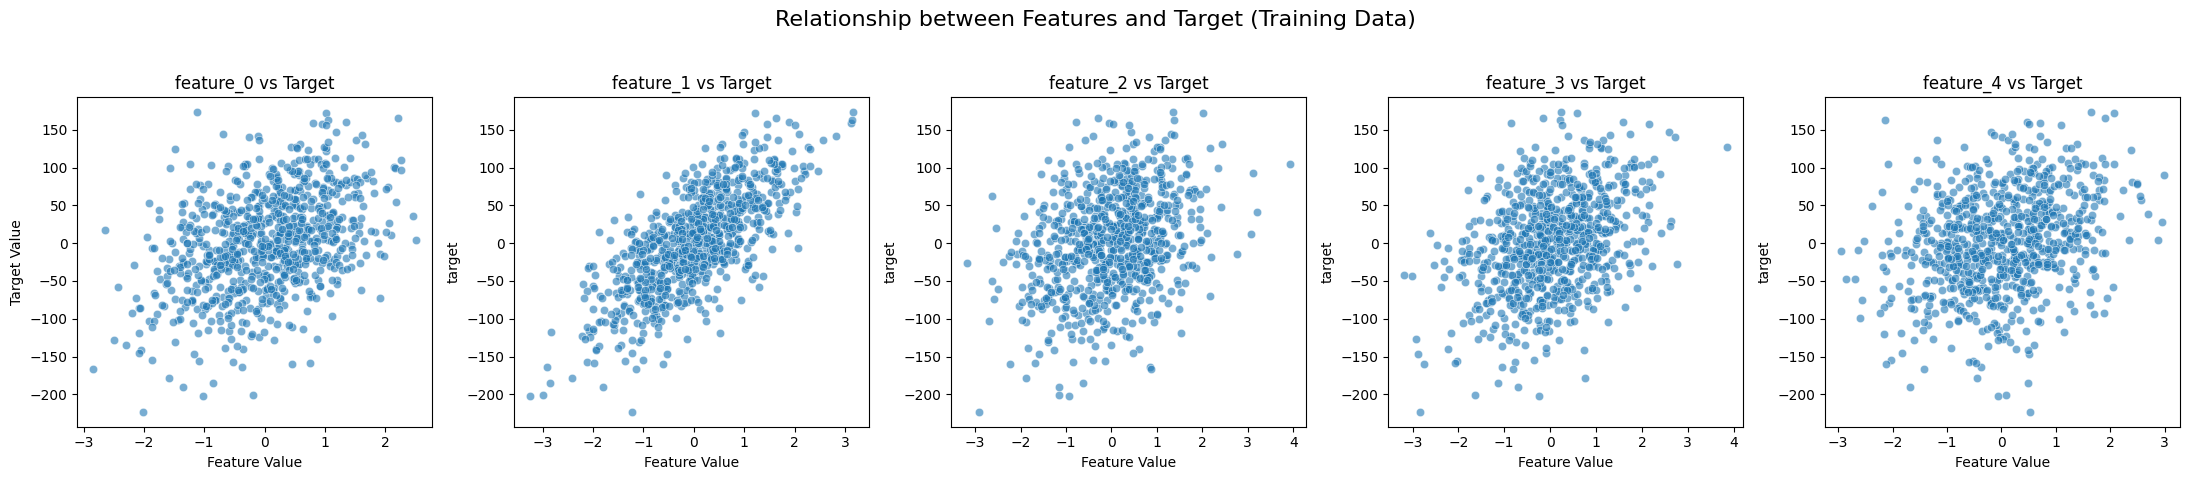

In [8]:
# plotting the graph

train_df = X_train.copy()
train_df['target'] = y_train


fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Relationship between Features and Target (Training Data)', fontsize=16)

for i, col in enumerate(X.columns):
    sns.scatterplot(ax=axes[i], x=train_df[col], y=train_df['target'], alpha=0.6)
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel('Feature Value')
    if i == 0:
        axes[i].set_ylabel('Target Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Gradient Boosting and Outliers (Simplified)

1.  **Outliers in Features ($X$):** **Robust** (Handles them well).
    *   Since trees use **splits** (e.g., `feature > 50`) rather than calculating mathematical distances, a value of `10,000` is treated the same as `51`. The model isn't "pulled" by extreme values in your input columns.
2.  **Outliers in the Target ($y$):** **Sensitive** (Weak by default).
    *   By default, it uses **`'squared_error'`**, which squares every mistake. A large outlier in the target creates a **massive residual**, forcing the next tree to focus entirely on that one noisy data point.
3.  **The `'absolute_error'` Solution:** Makes the model "Outlier-Proof."
    *   It treats errors linearly instead of squaring them. This prevents the model from being distracted by extreme values in the target.
4.  **The `'huber'` Solution:** The "Best of Both Worlds."
    *   It acts like **`'squared_error'`** for small, normal mistakes to keep the model precise.
    *   It automatically switches to **`'absolute_error'`** for large, outlier mistakes to keep the model robust.
5.  **The `'alpha'` Parameter:** The "Outlier Sensitivity."
    *   Only used with `'huber'`. It decides the point where a regular error becomes an "extreme outlier." A value like `0.9` tells the model to treat the top 10% of largest errors as outliers.




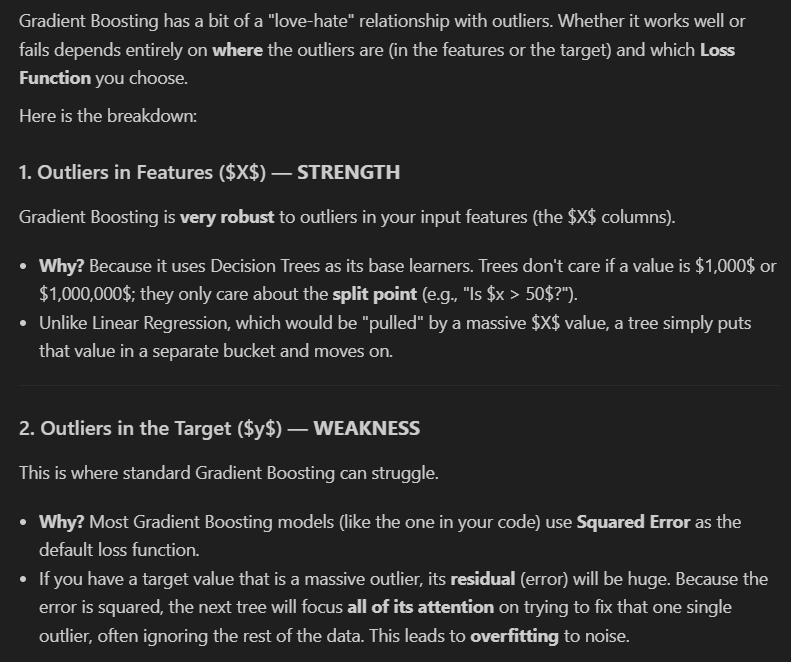
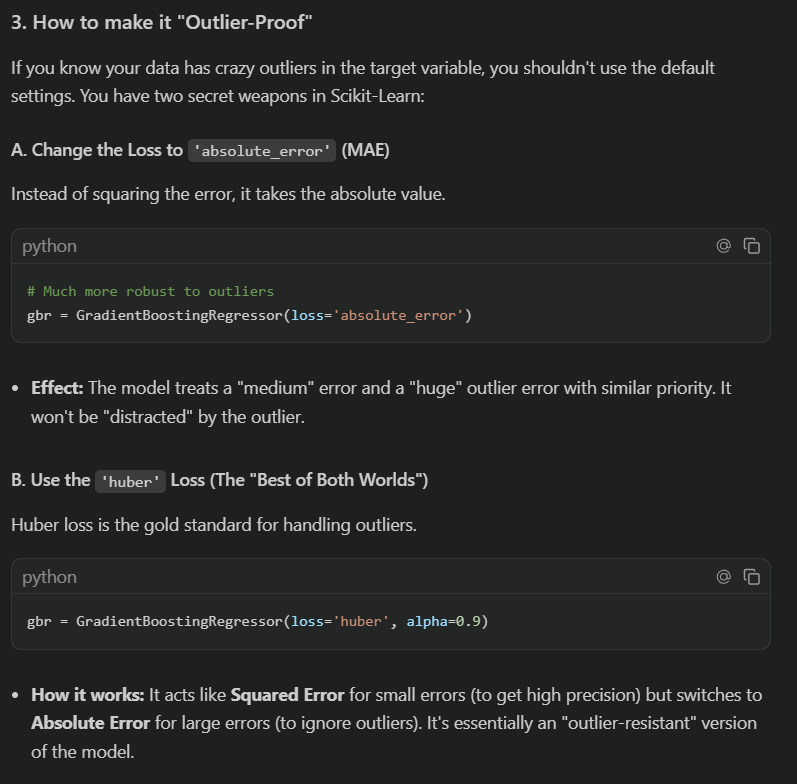


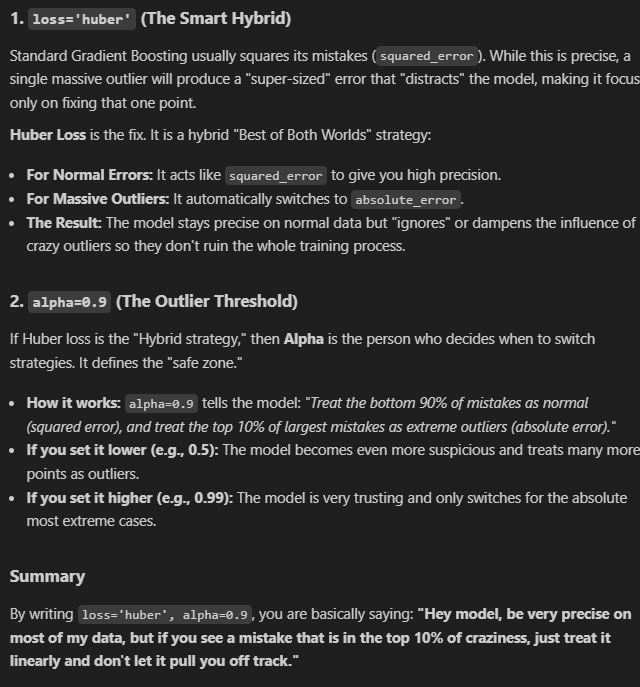

In [9]:
#training the model 
gbr = GradientBoostingRegressor(
    n_estimators=1000,       # 100 decision trees
    learning_rate=0.1,
    max_depth=5,
    loss='huber',           # keep in mind that 'huber' is regression only parameter
    alpha=0.9,
    random_state=42,
    n_iter_no_change=10,
    validation_fraction=0.2,       # 20% of the training data for validation / for testing (this 20% is not used for training)
    tol=0.1
)

# just comment out n_iter_no_change, validation_fraction, tol to see the difference

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"R2 : {r2_score(y_test, y_pred)}")

print(f"The model stopped training after {gbr.n_estimators_} iterations.")      # after 382 trees the model stops computing, saving the further computations

MSE : 209.73341370646426
R2 : 0.9432054856242474
The model stopped training after 382 iterations.


#### **Explaining `n_iter_no_change`, `tol`, `validation_fraction`**

Early stopping in Gradient Boosting is like a master strategy for training your model efficiently using a "hidden exam," a "benchmark," and a "lifeline."

The process begins with the `validation_fraction`, which acts as a hidden exam. Before any training starts, the model takes a small piece of your data (like 10%) and hides it in a drawer. This data is never used to actually build the trees; its only job is to provide a fresh, unbiased test after every round to see if the model is truly getting smarter or just memorizing the training data.

To decide if the model is actually improving, we use `tol` (tolerance) as our benchmark. After each tree is added, the model checks its performance on that hidden exam. If the improvement in the score is tiny or non-existent, the `tol` rule kicks in and tells the model that the current round was a failure because it didn't meet the minimum passing grade for meaningful progress.

This is where your `n_iter_no_change` becomes a vital lifeline. If a tree fails to beat the benchmark, the model doesn't quit immediately; instead, it starts a countdown based on your patience level. If you set this to 10, the model gets a 10-tree lifeline—brand new chances to find a better pattern. If any tree within those 10 chances manages to beat the benchmark, the countdown is wiped clean, and the lifeline is fully restored so the process can continue.

Finally, if the model exhausted its entire lifeline—meaning it built 10 different trees in a row without once beating the benchmark—the entire boosting process stops right there. By finishing this way, the model avoids extra computational work and protects itself from overfitting. It essentially pulls the emergency brake at its peak performance, ensuring you get the best possible version of the model without wasting time on unnecessary iterations.


FEATURE IMPORTANCE : 
feature_0    0.166286
feature_1    0.547745
feature_2    0.051618
feature_3    0.148692
feature_4    0.085659
dtype: float64


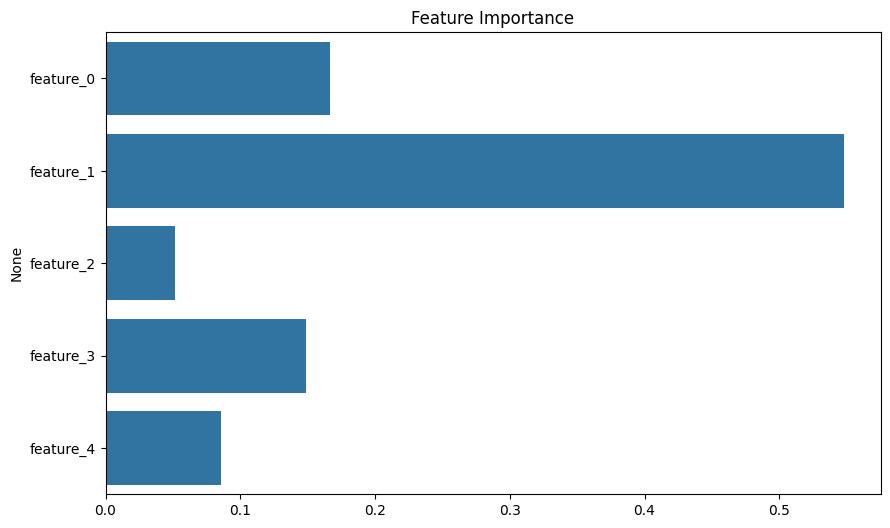

In [10]:
# checking for feature importance
print(f"\nFEATURE IMPORTANCE : \n{pd.Series(gbr.feature_importances_, index=X.columns)}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=gbr.feature_importances_, y=X.columns)
plt.title("Feature Importance")
plt.show()


### Gradient Boosting Regressor Hyperparameters (Simplified)

1.  **loss**: The "error rule." It tells the model how to measure its mistakes. 
    *   `'squared_error'`: Standard for regression.
    *   `'absolute_error'`: Better if your data has many outliers.
2.  **learning_rate**: The "step size." It controls how much each new tree corrects the mistakes of the previous ones.
    *   *Low value (e.g., 0.01)*: Learns slowly and carefully, usually needs more trees, but often results in better accuracy.
3.  **n_estimators**: The "number of trees." 
    *   More trees can make the model stronger, but too many can lead to **overfitting** (where the model memorizes the data instead of learning patterns).
4.  **subsample**: The "data fraction." 
    *   If set to 0.8, each tree only sees 80% of the data. This adds randomness and helps prevent the model from getting too focused on specific data points.
5.  **max_depth**: The "tree height."
    *   Limits how deep each individual tree can grow. Shallow trees (depth 3-5) are usually best for Gradient Boosting to keep the model simple.
6.  **min_samples_split**: The "split limit."
    *   The minimum number of data points needed in a group before the model is allowed to split it into smaller branches.
7.  **min_samples_leaf**: The "leaf limit."
    *   The minimum number of data points that must end up in a final "leaf" (the end of a branch). Higher numbers prevent the model from making decisions based on just 1 or 2 points.
8.  **max_features**: The "column limit."
    *   The number of features (columns) the model looks at when deciding a split. Reducing this can make the model faster and less likely to overfit.
9.  **alpha**: The "outlier sensitivity."
    *   Only used with specific loss functions (like 'huber'). It helps the model decide the cutoff point for what is considered an extreme outlier.
10. **n_iter_no_change**: "Early stopping."
    *   Tells the model to stop adding trees if the score isn't improving anymore, saving time and preventing overfitting.

